---
## 🎁 가산점

### A. 데이터의 다양성
- NTP ICE 내 다양한 데이터셋 모두 활용 가능. (https://ice.ntp.niehs.nih.gov/DATASETDESCRIPTION)


본 과제에서는 acute_oral toxicity 데이터(Template 1, Template 2)에 더해, acute_inhalation toxicity(급성 흡입독성) 데이터를 NTP ICE에서 추가로 확보하여 동일한 파이프라인을 적용하였습니다.

- acute_inhalation_data_pipeline.ipynb: acute_oral의 Template 1 형식을 그대로 따르되, LC50·mg/L 단위, GHS 흡입독성 Category 4 컷오프(20 mg/L)처럼 흡입독성 데이터에 맞게 조정한 전처리 노트북 (SMILES 표준화, 중복/label 충돌 제거 등 핵심 원칙은 동일)
- acute_inhalation_ml_model_pipeline.ipynb: 동일한 5종 알고리즘 비교 및 하이퍼파라미터 탐색을 적용한 Template 2 형식 노트북
- comparison_analysis.ipynb: 두 데이터셋(acute_oral, acute_inhalation)의 전처리 단계별 데이터 규모, label 분포, 모델 성능, feature importance를 비교 분석. acute_oral과 acute_inhalation은 노출 경로만 다를 뿐 '단회 노출에 대한 전신 독성 평가'라는 동일한 목적을 가진 GHS six-pack 시험의 자매 endpoint이며, 동일한 파이프라인이 두 데이터셋 모두에서 일관되게 작동함을 확인했습니다.
  또한 두 모델 모두에서 TPSA 등 공통 descriptor가 상위 importance를 차지한다는 점을 통해, 노출 경로가 달라도 일부 화학적 특성이 급성 독성 예측에 공통적으로 중요하게 작용한다는 점을 확인했습니다.

  
### B. Feature(descriptor)의 다양성
- rdkit, VEGA, 등

RDKit 2D descriptor와 Morgan fingerprint 두 종류를 함께 사용하여 구조 기반 feature와 비트 기반 feature를 반영하였습니다.

### 💬 추가 설명 (자유 기술)

# 기말고사 Template 1 - Data Pipeline

**이름:** __이나연__ &nbsp; **학번:** __20251258__

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **1. 데이터 분포 파악 및 전처리** | 15점 | 모델 개발 전, 중복 화합물 체크, smiles 코드 정리 등 모델 개발 전 확인해야 할 사항들을 확인. |
| **2. Descriptor 계산** | 15점 | 모델 개발에 사용할 descriptor의 다양성 |
| **3. 데이터 시각화 자료** | 15점 | 구조 분포, 라벨 비율 등 데이터 현황을 시각화한 자료 |
| **4. 코드 가독성 & 주석** | 5점 | 변수의 의미와 코드의 간결성을 평가. |

#### A. 데이터 소스의 다양성
- NTP ICE에서 구할 수 있는 다양한 데이터
- NTP ICE 외 추가 데이터 확보

## 📁 입력 / 출력 예시
- **입력**: `skin_irritation.xlsx` (NTP ICE) + (선택) 외부 데이터 (데이터가 여러개인 경우 xlsx파일의 zip으로 제출)
- **출력**: `final_dataset_descriptors.csv`  (Chemical_Name, SMILES, label, 2D descriptor [+ fingerprint 등])


---

## 사용 데이터
- 입력 파일: `C:\Users\elsan\Downloads\acute_oral.xlsx`
- 데이터 출처: NTP ICE acute oral toxicity 데이터
- 분석 대상: `Mixture == Chemical`, `Endpoint == LD50`, 유효한 `SMILES`가 있는 화합물
- 최종 출력: `C:/Users/elsan/Downloads/final_dataset_descriptors.csv`

## Label 정의
LD50은 급성 경구 독성을 나타내는 대표 지표이며, 값이 낮을수록 독성이 강하다는 의미.

- `label = 1`: acute toxic, `LD50 <= 2000 mg/kg`
- `label = 0`: lower toxicity, `LD50 > 2000 mg/kg`

`Response_Modifier`가 `>` 또는 `<`인 경우, 2000 mg/kg 기준으로 라벨을 명확히 판단할 수 있는 행만 사용하고 애매한 행은 제거했습니다.

---

In [1]:
!pip install rdkit

In [2]:
# 1. 라이브러리 불러오기

# warnings: RDKit이나 pandas에서 나오는 비치명적 경고를 화면에 출력하지 않도록 미리 꺼둠.
import warnings
warnings.filterwarnings('ignore')   # 이후 발생하는 모든 경고 메시지 무시

# numpy: 배열/수치 연산용 라이브러리
import numpy as np

# pandas: 표 형태(DataFrame) 데이터를 다루는 핵심 라이브러리.
import pandas as pd

# matplotlib: 그래프를 그리는 기본 시각화 라이브러리.
import matplotlib.pyplot as plt

# seaborn: matplotlib을 더 보기 좋게 감싸주는 통계 시각화 라이브러리.
import seaborn as sns

# RDKit: 화학 구조(분자)를 다루는 화학정보학(cheminformatics) 라이브러리.
#   Chem: SMILES <-> 분자 객체 변환, 분자 조작 기능
#   RDLogger: RDKit 내부 로그(경고/에러) 출력 제어
#   DataStructs: 분자 지문(fingerprint)을 numpy 배열로 변환하는 등 자료구조 변환 도구

from rdkit import Chem, RDLogger, DataStructs

# Descriptors: 분자량, 극성 표면적, 수소결합 개수 등 분자의 2D 물리화학적 특성 계산
# AllChem: Morgan fingerprint 등 고급 화학 계산 기능

from rdkit.Chem import Descriptors, AllChem

# RDKit이 SMILES를 파싱하다가 실패할 때마다 콘솔에 찍는 내부 경고 로그를 끔.
RDLogger.DisableLog('rdApp.*')

# 그래프에서 한글이 깨지지 않도록 폰트를 '맑은 고딕'으로 지정.
plt.rc('font', family='Malgun Gothic')

# 음수 기호(-)가 한글 폰트에서 깨지는 matplotlib의 알려진 버그를 방지하는 설정.
plt.rcParams['axes.unicode_minus'] = False

# seaborn 전체 그래프의 기본 테마를 흰색 격자 배경으로 통일.
sns.set_style('whitegrid')

In [3]:
# 2. 데이터 불러오기 및 기본 구조 확인

# 원본 엑셀 파일 경로 (Windows 로컬 경로. 다른 PC에서 실행 시 수정 필요)
input_path = r'C:\Users\elsan\Downloads\acute_oral.xlsx'

# 최종 결과(descriptor 포함 데이터셋)를 저장할 CSV 경로
output_path = r'C:/Users/elsan/Downloads/final_dataset_descriptors.csv'

# pd.ExcelFile: 엑셀 파일을 한 번만 열어서 시트 이름 목록 등 메타정보를 확인하기 위한 객체.
excel_file = pd.ExcelFile(input_path)
print('시트 목록:', excel_file.sheet_names)  # 'Metadata', 'Data' 두 시트가 있는지 확인

# 실제 데이터가 들어있는 'Data' 시트만 읽어서 DataFrame으로 불러옴
df_raw = pd.read_excel(input_path, sheet_name='Data')
print('원본 데이터 크기:', df_raw.shape)  # (행 개수, 열 개수) 확인
display(df_raw.head())  # 상위 5행을 표로 미리 확인 (데이터가 제대로 읽혔는지 검증)

print()
print('컬럼 목록')
print(df_raw.columns.tolist())  # 전체 컬럼명을 리스트로 출력해서 이후 필터링에 쓸 컬럼명을 확인


시트 목록: ['Metadata', 'Data']
원본 데이터 크기: (16721, 23)


,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Mixture,Species,...,Response_Modifier,Response,Response_Unit,Reference,URL,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
0,acute_oral_12325,In Vivo,MIX86,Captevate 68 WDG,Captan-related-substance,NaN,NaN,1.200,Mixture,Rat,...,NaN,5.0,Unitless,Studies submitted to EPA in support of pestici...,NaN,NaN,NaN,NaN,NaN,NaN
1,acute_oral_12322,In Vivo,MIX82,Captan 4L,Captan-related-substance,NaN,NaN,0.970,Mixture,Rat,...,>,5000.0,mg/kg,Studies submitted to EPA in support of pestici...,NaN,NaN,NaN,NaN,NaN,NaN
2,acute_oral_12133,In Vivo,MIX617,5-Hydroxy-Tepraloxydim,Tepraloxydim-5-hydroxy,15479-55-0,NaN,89.600,Mixture,Rat,...,>,5000.0,mg/kg,Studies submitted to EPA in support of pestici...,NaN,NaN,NaN,NaN,NaN,NaN
3,acute_oral_12132,In Vivo,MIX617,5-Hydroxy-Tepraloxydim,Tepraloxydim-5-hydroxy,15479-55-0,NaN,89.600,Mixture,Rat,...,>,5000.0,mg/kg,Studies submitted to EPA in support of pestici...,NaN,NaN,NaN,NaN,NaN,NaN
4,acute_oral_12894,In Vivo,MIX380,Raid Roach & Ant Killer Plus,Dichlorvos-related-substance,NaN,NaN,0.014,Mixture,Rat,...,NaN,3710.0,mg/kg,Studies submitted to EPA in support of pestici...,NaN,NaN,NaN,NaN,NaN,NaN



컬럼 목록
['Record_ID', 'Data_Type', 'Formulation_ID', 'Formulation_Name', 'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient', 'Mixture', 'Species', 'Sex', 'Assay', 'Endpoint', 'Response_Modifier', 'Response', 'Response_Unit', 'Reference', 'URL', 'SMILES', 'Preferred_Name', 'Synonyms', 'URL_CompTox', 'URL_CEBS']


In [4]:
# 3. 전처리 전 데이터 분포 확인

# 본격적으로 필터링하기 전에, 주요 범주형 컬럼들이 어떤 값들로 구성되어 있는지 미리 눈으로 확인
summary_cols = ['Data_Type', 'Mixture', 'Species', 'Sex', 'Assay', 'Endpoint', 'Response_Unit', 'Response_Modifier']
for col in summary_cols:
    print()
    print(f'[{col}]')
    # value_counts(dropna=False): 각 값이 몇 번 등장하는지 빈도수를 계산.
    # dropna=False로 결측치(NaN)도 하나의 범주처럼 함께 셈 (결측 비율 파악).
    # head(20): 값 종류가 많을 수 있으므로 상위 20개만 출력
    display(df_raw[col].value_counts(dropna=False).head(20))

print()
# 이후 분석에서 SMILES(분자 구조 문자열)가 필수이므로, 결측/보유 개수를 미리 확인
print('SMILES 결측 개수:', df_raw['SMILES'].isna().sum())
print('SMILES 보유 개수:', df_raw['SMILES'].notna().sum())



[Data_Type]


Data_Type
In Vivo    16721
Name: count, dtype: int64


[Mixture]


Mixture
Chemical    12207
Mixture      4514
Name: count, dtype: int64


[Species]


...


[Response_Unit]


Response_Unit
mg/kg       13512
Unitless     3209
Name: count, dtype: int64


[Response_Modifier]


Response_Modifier
NaN    12440
>       3857
<        424
Name: count, dtype: int64


SMILES 결측 개수: 484
SMILES 보유 개수: 16237


In [5]:
# 4. 과제용 데이터 필터링
# 단일 화학물질이며 LD50 값과 SMILES가 있는 행만 선택

# 원본을 직접 건드리지 않기 위해 복사본을 생성
df = df_raw.copy()

# 조건 1: Mixture 컬럼 값이 'chemical'인 행만 선택
#   .astype(str): 혹시 NaN이나 다른 타입이 섞여 있어도 문자열로 통일
#   .str.strip(): 앞뒤 공백 제거=
#   .str.lower(): 대소문자 차이로 비교가 틀어지는 것을 방지
#   .eq('chemical'): 정확히 'chemical'과 같은지 비교한 True/False 시리즈 반환
cond_chemical = df['Mixture'].astype(str).str.strip().str.lower().eq('chemical')

# 조건 2: Endpoint 컬럼 값이 'LD50'인 행만 선택 (대문자로 통일해서 비교)
cond_ld50 = df['Endpoint'].astype(str).str.strip().str.upper().eq('LD50')

# 조건 3: SMILES가 결측이 아닌 행만 선택
#   -> SMILES가 없으면 이후 RDKit으로 분자 구조/descriptor를 계산할 수 없으므로 필수 조건
cond_smiles = df['SMILES'].notna()

# 조건 4: Response(LD50 수치값)가 결측이 아닌 행만 선택
cond_response = df['Response'].notna()

# 위 4가지 조건을 모두 만족하는(&: AND) 행만 골라서 새 DataFrame 생성
df_ld50 = df[cond_chemical & cond_ld50 & cond_smiles & cond_response].copy()

# Response 컬럼이 엑셀에서 문자열로 들어와 있을 가능성에 대비해 숫자형으로 강제 변환.
# errors='coerce': 숫자로 변환할 수 없는 값은 NaN으로 처리
df_ld50['Response'] = pd.to_numeric(df_ld50['Response'], errors='coerce')

# 위 변환 과정에서 새로 NaN이 된 행(숫자로 변환 불가능했던 값)을 제거
df_ld50 = df_ld50.dropna(subset=['Response'])

print('필터링 후 데이터 크기:', df_ld50.shape)

# 필터링이 의도대로 잘 됐는지 주요 컬럼 미리보기
display(df_ld50[['Chemical_Name', 'Species', 'Endpoint', 'Response_Modifier', 'Response', 'Response_Unit', 'SMILES']].head())


필터링 후 데이터 크기: (11948, 23)


,Chemical_Name,Species,Endpoint,Response_Modifier,Response,Response_Unit,SMILES
46,(2-Chloropyridin-3-yl)(phenyl)methanol,Rat,LD50,>,2000.0,mg/kg,OC(C1=CC=CC=C1)C1=C(Cl)N=CC=C1
47,"2-(4-Methoxyphenyl)-5,6-dihydro-2H-1,3-thiazin...",Rat,LD50,>,8000.0,mg/kg,COC1=CC=C(C=C1)C1SCCC(O)=N1
48,"Bis(2-ethylhexyl) cyclohexane-1,4-dicarboxylate",Rat,LD50,>,2000.0,mg/kg,CCCCC(CC)COC(=O)C1CCC(CC1)C(=O)OCC(CC)CCCC
49,2-Methyl-6-methylideneoctyl acetate,Rat,LD50,>,5000.0,mg/kg,CCC(=C)CCCC(C)COC(C)=O
50,"O,S-Dimethyl propylphosphonothioate",Rat,LD50,NaN,25.0,mg/kg,CCCP(=O)(OC)SC


In [6]:
# 5. LD50 기준 이진 label 생성
# Response_Modifier가 있어도 threshold 기준으로 명확히 판정 가능한 행만 사용.

# 독성 판정 기준값: LD50 <= 2000 mg/kg이면 급성독성(1), 초과하면 저독성(0)
threshold = 2000

# 한 행을 받아서 label(0, 1, 또는 판정불가 시 NaN)을 반환하는 함수.
# Response_Modifier는 실험값이 '정확한 값'이 아니라 '>' 또는 '<'로만 보고된 경우를 나타내는 컬럼
def make_ld50_label(row):
    value = row['Response']         # LD50 수치
    modifier = row['Response_Modifier']  # 부등호 표시 (>, <, 또는 NaN=정확한 값)

    # modifier가 없으면(NaN) Response 값이 정확한 측정값이라는 뜻 -> 그냥 threshold와 직접 비교
    if pd.isna(modifier):
        return 1 if value <= threshold else 0

    modifier = str(modifier).strip()
    # modifier가 '>' 인 경우: 실제 LD50은 value보다 더 크다는 뜻.
    #   만약 value 자체가 이미 threshold(2000) 이상이면, 실제 값도 당연히 2000 이상이므로 안전하게 label=0(저독성)으로 확정 가능.
    #   하지만 value가 threshold보다 작다면(예: ">1500"), 실제 값이 1500~무한대 사이의 어딘가. 2000을 넘는지 알 수 없으므로 판정 불가 -> NaN
    if modifier == '>':
        if value >= threshold:
            return 0
        return np.nan
    # modifier가 '<' 인 경우: 실제 LD50은 value보다 더 작다는 뜻.
    #   value 자체가 이미 threshold 이하라면, 실제 값도 당연히 그보다 작으므로 안전하게 label=1(급성독성)로 확정 가능.
    #   value가 threshold보다 크다면(예: "<2500") 실제 값이 0~2500 사이 어딘가, 2000 기준으로 확정할 수 없으므로 판정 불가 -> NaN
    if modifier == '<':
        if value <= threshold:
            return 1
        return np.nan
    # 위 두 경우(>, <)가 아닌 다른 modifier 값이 있다면 판정 불가로 처리
    return np.nan

# 각 행에 위 함수를 적용하여 label 컬럼 생성 (axis=1: 행 단위로 함수 적용)
df_ld50['label'] = df_ld50.apply(make_ld50_label, axis=1)

# label이 NaN인(=판정이 애매해서 보류된) 행이 몇 개인지 카운트
ambiguous_n = df_ld50['label'].isna().sum()

# label이 명확히 결정된 행만 남기고 애매한 행은 제거
df_labeled = df_ld50.dropna(subset=['label']).copy()

# label을 실수형(float, NaN 처리 때문에 생긴 타입)에서 정수형(int)으로 변환
df_labeled['label'] = df_labeled['label'].astype(int)

print('라벨 판정이 애매해서 제거한 행 수:', ambiguous_n)
print('라벨 생성 후 데이터 크기:', df_labeled.shape)
print()
print('Label 분포')

# 0과 1이 각각 몇 개인지 확인 (클래스 불균형 여부 확인)
display(df_labeled['label'].value_counts().rename(index={0: '0_lower_toxicity', 1: '1_acute_toxic'}))


라벨 판정이 애매해서 제거한 행 수: 910
라벨 생성 후 데이터 크기: (11038, 24)

Label 분포


label
1_acute_toxic       6181
0_lower_toxicity    4857
Name: count, dtype: int64

In [7]:
# 6. SMILES 표준화 및 salt/fragment 정리
# RDKit이 읽을 수 없는 SMILES는 제거, 여러 fragment가 있으면 가장 큰 fragment를 대표 구조로 사용.

# SMILES 문자열 하나를 입력받아 '표준화된' SMILES 문자열로 변환하는 함수.
# 같은 분자라도 SMILES 표기법은 여러 가지가 가능하므로, 이후 같은 화합물인지 비교하려면 모두 동일한 규칙으로 통일된 표기로 바꿔야 함.
def standardize_smiles(smiles):
    # 입력이 NaN이거나 문자열이 아니면 처리할 수 없으므로 None 반환
    if pd.isna(smiles) or not isinstance(smiles, str):
        return None

    # SMILES 문자열을 RDKit의 분자 객체(Mol)로 변환 시도.
    # 문법이 잘못된 SMILES이면 None이 반환됨
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # GetMolFrags: 분자 안에 서로 연결되지 않은 여러 조각(fragment)이 있으면 분리.
    # asMols=True: 각 fragment를 별도의 Mol 객체 리스트로 반환
    # sanitizeFrags=True: 분리된 각 fragment에 대해 화학적 유효성 검사(sanitize)를 수행
    fragments = Chem.GetMolFrags(mol, asMols=True, sanitizeFrags=True)
    if len(fragments) == 0:
        return None

    # 여러 fragment 중에서 무거운 원자 개수가 가장 많은 fragment를 대표 구조로 선택.
    # 보통 염의 경우 작은 이온보다 실제 약효/독성을 가진 본체 분자 쪽이 원자 수가 훨씬 많기 때문.
    main_mol = max(fragments, key=lambda m: m.GetNumHeavyAtoms())
    
    # 선택된 fragment가 원자가 0개(빈 분자)라면 비정상적인 경우이므로 제외
    if main_mol.GetNumHeavyAtoms() == 0:
        return None

    # 선택된 대표 fragment를 다시 SMILES 문자열로 변환.
    # canonical=True: RDKit의 표준 규칙에 따라 항상 동일한 형태의 문자열로 생성
    # (같은 분자는 항상 똑같은 문자열이 나오도록 보장 -> 이후 중복 비교에 사용 가능)
    return Chem.MolToSmiles(main_mol, canonical=True)

# df_labeled의 모든 SMILES에 위 함수를 적용해서 새 컬럼 'standardized_smi' 생성
df_labeled['standardized_smi'] = df_labeled['SMILES'].apply(standardize_smiles)

# 표준화에 실패한(None이 된) 행은 제거하고 유효한 행만 남김
df_valid = df_labeled.dropna(subset=['standardized_smi']).copy()

print('SMILES 표준화 전:', len(df_labeled))
print('SMILES 표준화 후:', len(df_valid))

# 원본 SMILES와 표준화된 SMILES를 나란히 비교해서 잘 변환됐는지 눈으로 확인
display(df_valid[['Chemical_Name', 'SMILES', 'standardized_smi', 'label']].head())


SMILES 표준화 전: 11038
SMILES 표준화 후: 11031


,Chemical_Name,SMILES,standardized_smi,label
46,(2-Chloropyridin-3-yl)(phenyl)methanol,OC(C1=CC=CC=C1)C1=C(Cl)N=CC=C1,OC(c1ccccc1)c1cccnc1Cl,0
47,"2-(4-Methoxyphenyl)-5,6-dihydro-2H-1,3-thiazin...",COC1=CC=C(C=C1)C1SCCC(O)=N1,COc1ccc(C2N=C(O)CCS2)cc1,0
48,"Bis(2-ethylhexyl) cyclohexane-1,4-dicarboxylate",CCCCC(CC)COC(=O)C1CCC(CC1)C(=O)OCC(CC)CCCC,CCCCC(CC)COC(=O)C1CCC(C(=O)OCC(CC)CCCC)CC1,0
49,2-Methyl-6-methylideneoctyl acetate,CCC(=C)CCCC(C)COC(C)=O,C=C(CC)CCCC(C)COC(C)=O,0
50,"O,S-Dimethyl propylphosphonothioate",CCCP(=O)(OC)SC,CCCP(=O)(OC)SC,1


In [8]:
# 7. 중복 화합물 및 label 충돌 처리
# 같은 standardized_smi에 서로 다른 label이 있으면 분석 기준이 흔들리므로 제거.

# 같은 화합물(standardized_smi가 동일)이 데이터셋에 여러 번 등장하는 행이 몇 개인지 확인
print('표준화 SMILES 기준 중복 행 수:', df_valid.duplicated('standardized_smi').sum())

# 같은 standardized_smi를 가진 행들을 그룹으로 묶고, 그 그룹 안에서 label의 종류 개수를 계산한 뒤, 원래 행 개수만큼 다시 펼쳐서 각 행에 매칭.
# 즉 어떤 화합물이 한 그룹 내에서 label이 1과 0 둘 다 있으면 그 값은 2가 됨.
label_nunique = df_valid.groupby('standardized_smi')['label'].transform('nunique')

# nunique> 1 인 행들= 같은 화합물이 어떤 실험에서는 독성(1), 다른 실험에서는 저독성(0)으로 측정되어 라벨이 서로 충돌하는 경우, 신뢰할 수 없으므로 분리
conflict_df = df_valid[label_nunique > 1].copy()

# nunique == 1 인 행들= 같은 화합물에 대해 모든 실험이 동일한 label로 일치하는 경우
consistent_df = df_valid[label_nunique == 1].copy()

print('label 충돌 행 수:', len(conflict_df))
print('label 충돌 제거 후 행 수:', len(consistent_df))

# consistent_df 안에서도 같은 화합물이 여러 행으로 중복되어 있을 수 있으므로 화합물 1개당 1행으로 줄여야 함.

# [왜 최소값을 대표값으로 선택했는가]

# 1) label이 일치하는 행들끼리만 모았으므로 어떤 값을 골라도 label 자체는 바뀌지 않음.
#    즉 분류 결과에는 영향이 없고, Response 수치를 무엇으로 대표할지만 결정하는 문제이다.

# 2) 독성 평가에서는 일반적으로 보수적 기준을 선호.
#    여러 실험에서 LD50이 다르게 측정됐다면, 가장 작은 LD50을 대표값으로 두는 것이 안전 마진을 확보하는 방식이다.

# sort_values('Response'): Response(LD50 수치) 기준으로 오름차순 정렬 -> 같은 화합물의 여러 측정값 중 가장 작은 값이 맨 위로 오도록 정렬
# drop_duplicates(subset='standardized_smi', keep='first') -> 정렬된 상태에서 같은 standardized_smi가 여러 개면 첫 번째만 남김
df_final = consistent_df.sort_values('Response').drop_duplicates(subset='standardized_smi', keep='first').copy()

# 행을 걸러낸 뒤 인덱스가 0,1,2,... 순서로 깔끔하게 재배열되도록 초기화
df_final = df_final.reset_index(drop=True)

print('최종 unique compound 수:', len(df_final))
print()
print('최종 label 분포')
display(df_final['label'].value_counts().sort_index())


표준화 SMILES 기준 중복 행 수: 2920
label 충돌 행 수: 1061
label 충돌 제거 후 행 수: 9970
최종 unique compound 수: 7835

최종 label 분포


label
0    3492
1    4343
Name: count, dtype: int64

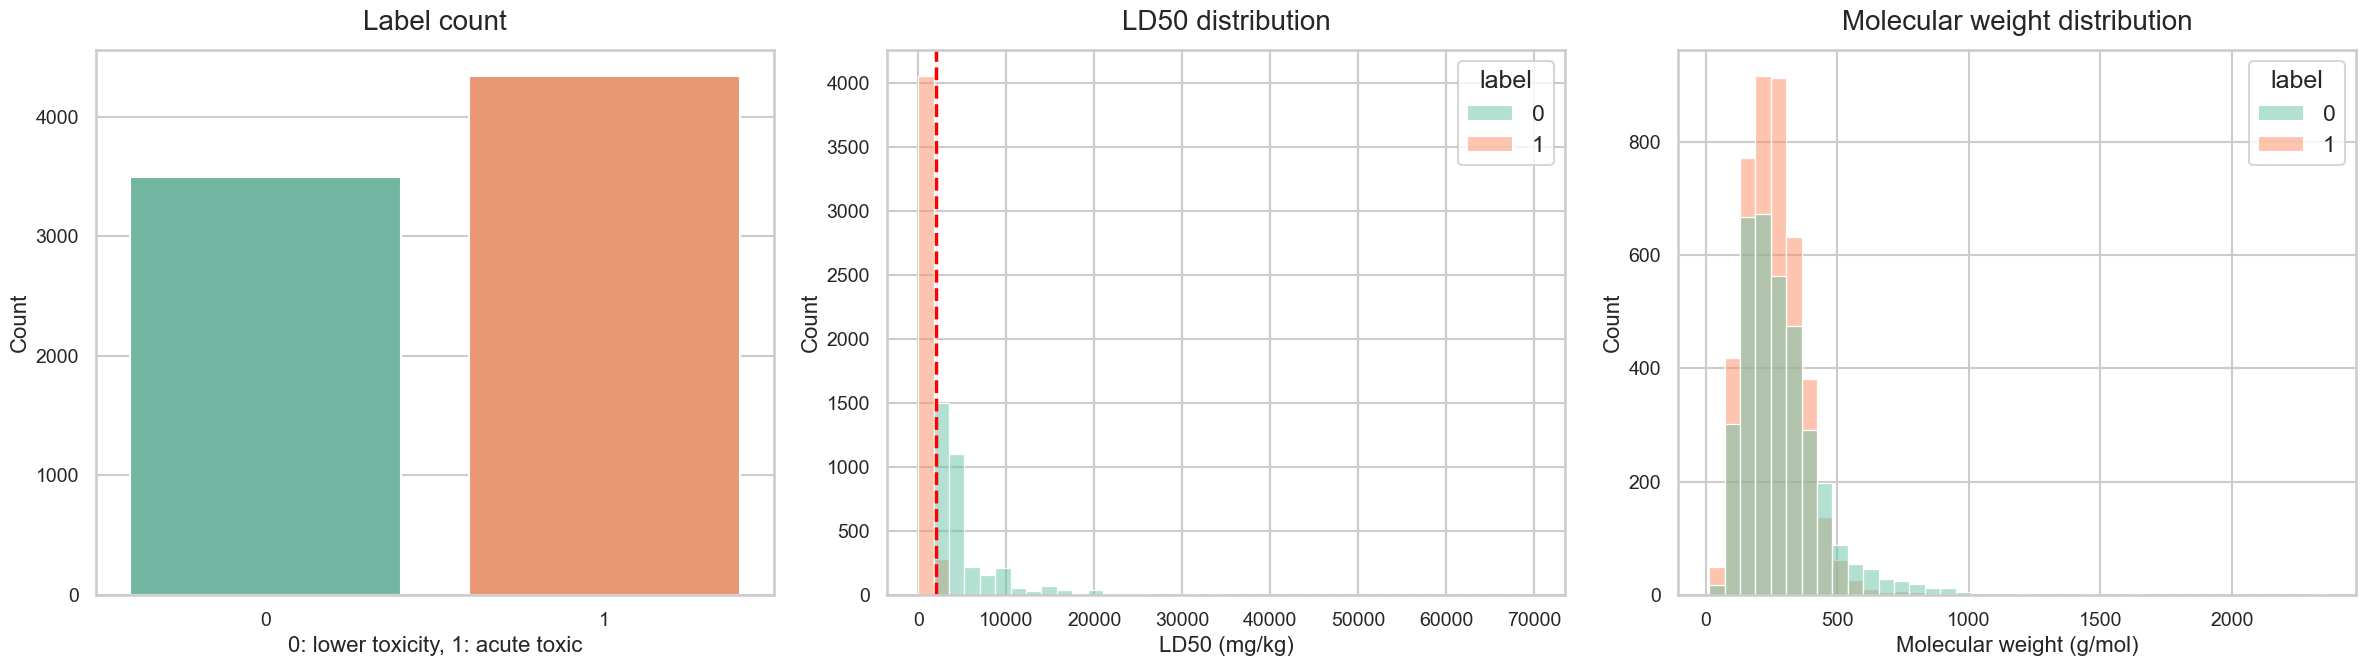

In [9]:
# 8. 데이터 시각화 - label, LD50, 분자량(MolWt) 분포
# 원래 3번째 그래프는 Species 분포였으나, 본 데이터셋의 Species는 Rat이 16498건으로 거의 전부.
# 즉 분포 정보로서 의미가 없다고 판단, 화합물의 구조적 특성을 보여주는 분자량 분포로 교체함.
# MolWt는 RDKit으로 SMILES만 있으면 바로 계산 가능하고,label에 따라 분자 크기 분포가 어떻게 다른지도 함께 확인 가능.

# seaborn의 전반적인 글자 크기/스타일을 설정
sns.set_context('talk')

# 1행 3열짜리 서브플롯 생성, 전체 그림 크기는 가로 24 x 세로 7
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# [그래프 1] label(0/1) 값별로 몇 개씩 있는지 막대그래프로 표시 -> 클래스 불균형 확인용
sns.countplot(data=df_final, x='label', ax=axes[0], palette='Set2')
axes[0].set_title('Label count', fontsize=20, pad=14)
axes[0].set_xlabel('0: lower toxicity, 1: acute toxic', fontsize=16)
axes[0].set_ylabel('Count', fontsize=16)
axes[0].tick_params(axis='both', labelsize=14)

# [그래프 2] LD50(Response) 값의 분포를 히스토그램으로 표시, label별로 색을 구분(hue)
#   bins=40: 막대를 40개 구간으로 나눠서 분포의 모양을 세밀하게 확인
sns.histplot(data=df_final, x='Response', hue='label', bins=40, ax=axes[1], palette='Set2')

# threshold(2000mg/kg) 위치에 수직 빨간 점선을 그려서 라벨링 기준선을 시각적으로 표시
axes[1].axvline(threshold, color='red', linestyle='--', linewidth=2.5, label='LD50 2000 mg/kg')
axes[1].set_title('LD50 distribution', fontsize=20, pad=14)
axes[1].set_xlabel('LD50 (mg/kg)', fontsize=16)
axes[1].set_ylabel('Count', fontsize=16)
axes[1].tick_params(axis='both', labelsize=14)

# [그래프 3] 화합물의 분자량(MolWt) 분포를 label별로 비교하는 히스토그램.
#   먼저 standardized_smi로부터 분자량을 계산해 새 컬럼으로 추가한다.
df_final['MolWt'] = df_final['standardized_smi'].apply(
    lambda smi: Descriptors.MolWt(Chem.MolFromSmiles(smi))
)

sns.histplot(data=df_final, x='MolWt', hue='label', bins=40, ax=axes[2], palette='Set2')
axes[2].set_title('Molecular weight distribution', fontsize=20, pad=14)
axes[2].set_xlabel('Molecular weight (g/mol)', fontsize=16)
axes[2].set_ylabel('Count', fontsize=16)
axes[2].tick_params(axis='both', labelsize=14)

# 서브플롯들 사이 여백을 자동으로 보기 좋게 조정
plt.tight_layout()
plt.show()


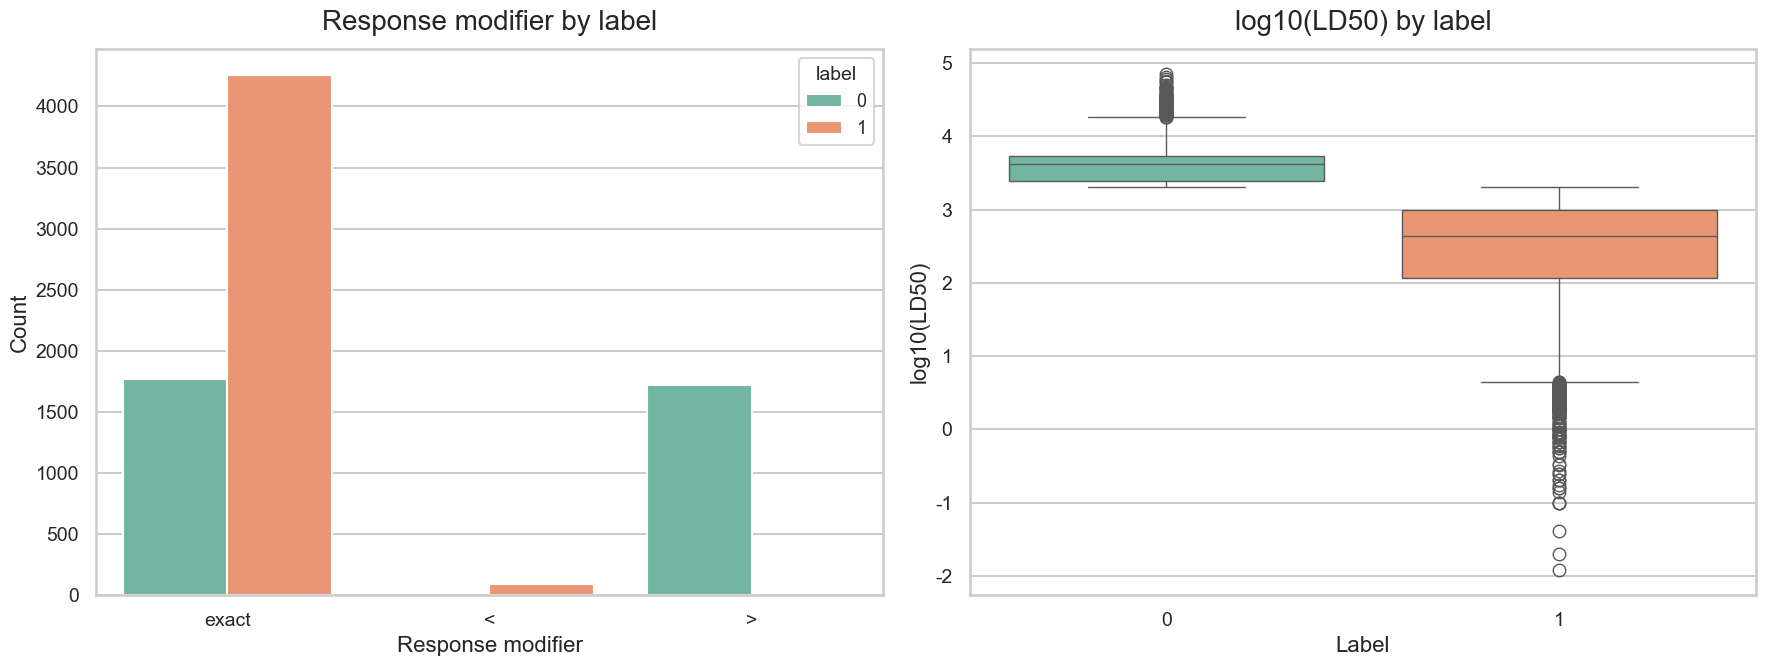

In [10]:
# 9. 데이터 시각화 - response modifier와 log LD50 분포

# 시각화 전용 복사본 생성 (df_final 원본은 그대로 보존)
plot_df = df_final.copy()

# LD50 값은 수십 mg/kg부터 수만 mg/kg까지 범위가 매우 넓게 퍼져 있어서,
# 그대로 그리면 작은 값들이 한쪽에 뭉쳐 보이므로 log10 변환을 해서 분포를 보기 좋게 펼침
plot_df['log10_LD50'] = np.log10(plot_df['Response'])

# Response_Modifier가 NaN인 행들을 그래프에서 구분하기 쉽게 'exact'라는 문자열로 채워서 새 컬럼 생성
plot_df['Response_Modifier_filled'] = plot_df['Response_Modifier'].fillna('exact')

sns.set_context('talk')

# 1행 2열 서브플롯 생성
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# [그래프 1] Response_Modifier 종류(exact, >, <)별로, label(0/1) 분포가 어떻게 다른지 막대그래프로 확인
sns.countplot(data=plot_df, x='Response_Modifier_filled', hue='label', ax=axes[0], palette='Set2')
axes[0].set_title('Response modifier by label', fontsize=20, pad=14)
axes[0].set_xlabel('Response modifier', fontsize=16)
axes[0].set_ylabel('Count', fontsize=16)
axes[0].tick_params(axis='both', labelsize=14)
axes[0].legend(title='label', fontsize=13, title_fontsize=14)

# [그래프 2] label(0/1)별로 log10(LD50) 값의 분포를 박스플롯(Box plot)으로 비교
#   -> 두 그룹의 중앙값/사분위/이상치 등을 한눈에 비교해서 라벨링이 실제로 독성 강도 차이를 잘 반영하고 있는지 시각적으로 검증
sns.boxplot(data=plot_df, x='label', y='log10_LD50', ax=axes[1], palette='Set2')
axes[1].set_title('log10(LD50) by label', fontsize=20, pad=14)
axes[1].set_xlabel('Label', fontsize=16)
axes[1].set_ylabel('log10(LD50)', fontsize=16)
axes[1].tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()


In [11]:
# 10. RDKit 2D descriptor 계산
# Descriptors.CalcMolDescriptors는 RDKit 기본 2D descriptor를 dictionary 형태로 반환한다.

# SMILES 하나를 받아서 그 분자의 2D descriptor를 계산하는 함수.
# 이 descriptor들이 머신러닝 모델의 입력 feature로 사용될 예정.
def calc_2d_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        # CalcMolDescriptors: RDKit에 내장된 모든 2D descriptor를 {descriptor 이름: 값} 형태의 딕셔너리로 계산해주는 함수
        return Descriptors.CalcMolDescriptors(mol)
    except Exception:
        # 일부 분자에서는 특정 descriptor 계산 중 수치 에러 발생 가능, 에러가 나면 그 화합물 전체를 None으로 처리하고 넘어감
        return None

desc_records = []   # 각 화합물의 descriptor 딕셔너리들을 모아둘 리스트
valid_indices = []  # descriptor 계산에 성공한 화합물의 원래 인덱스(행 번호)를 저장

# df_final의 'standardized_smi' 컬럼을 한 행씩 순회하며 descriptor 계산
# .items(): (인덱스, 값) 쌍을 하나씩 꺼내줌
for idx, smi in df_final['standardized_smi'].items():
    desc = calc_2d_descriptors(smi)
    if desc is not None:
        desc_records.append(desc)
        valid_indices.append(idx)

# 딕셔너리들의 리스트를 DataFrame으로 변환 (각 딕셔너리의 key가 컬럼명이 됨)
desc_df = pd.DataFrame(desc_records)

# descriptor 계산에 성공한 화합물들만, 식별 정보와 label/Response 컬럼을 따로 추려서 보관 (나중에 descriptor와 다시 합칠 기준 정보)
# reset_index(drop=True): valid_indices로 골라낸 행들의 인덱스를 0부터 다시 매김
#   (desc_df와 행 순서/개수를 정확히 맞추기 위해 필수)
df_desc_base = df_final.loc[valid_indices, ['Chemical_Name', 'CASRN', 'SMILES', 'standardized_smi', 'Response', 'Response_Unit', 'label']].reset_index(drop=True)

# 일부 descriptor는 계산 과정에서 무한대(inf)가 나올 수 있으므로 먼저 NaN으로 바꿔줌
desc_df = desc_df.replace([np.inf, -np.inf], np.nan)


# [왜 행 단위가 아니라 컬럼 단위로 NaN을 제거했는가]

# RDKit의 200여 개 2D descriptor 중에는 특정 분자 구조에서만 계산식이 정의되지 않아 NaN이 나오는 항목이 섞여 있음.
# 만약 행 단위로 제거했다면, 하나의 불안정한 descriptor 때문에 화합물 자체가 통째로 날아가서 데이터 손실이 커질 수 있음
# 컬럼 단위로 제거하면, 모든 화합물에 대해 안정적으로 계산되는 descriptor만 남기고 문제가 된 일부만 빠지는 대신 화합물 수는 그대로 보존됨.

# 샘플 수를 지키는 것과 feature 품질을 지키는 것 중 후자를 위해 컬럼 드롭 선택.
# 결과적으로 RDKit이 계산하는 약 217개의 2D descriptor 중 205개가 끝까지 살아남았으므로 feature 손실도 크지 않았음

# 참고: 최종 합본 데이터셋의 컬럼 수가 2260개로 나오는 것은 식별정보 7개 + descriptor 205개 + Morgan fingerprint 2048비트를 모두 합친 값.
#  descriptor 자체의 개수는 아님. 자세한 내용은 최종 데이터셋 저장 부분 참고.

# NaN 값이 하나라도 있는 descriptor '컬럼'은 통째로 제거 (axis=1: 컬럼 기준 제거)
desc_df = desc_df.dropna(axis=1)

print('Descriptor 계산 성공 화합물 수:', len(df_desc_base))
print('NaN 제거 후 descriptor 개수:', desc_df.shape[1])
display(desc_df.head())


Descriptor 계산 성공 화합물 수: 7835
NaN 제거 후 descriptor 개수: 205


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,5.676825,5.676825,0.345019,0.345019,0.605684,25.742857,480.649,440.329,480.298808,190,...,0,0,0,0,0,0,0,0,0,0
1,5.914545,5.914545,0.391229,0.391229,0.490572,12.222222,321.974,317.942,319.896540,92,...,0,0,0,0,0,0,0,0,0,0
2,13.011064,13.011064,0.077001,-5.771605,0.335502,35.361111,524.586,486.282,524.272514,206,...,0,0,0,0,0,0,0,0,0,0
3,5.822407,5.822407,0.686849,0.686849,0.345378,12.222222,499.778,495.746,495.694478,92,...,0,0,0,0,0,0,0,0,0,0
4,10.453704,10.453704,1.388889,-1.662037,0.390207,7.400000,77.034,75.018,77.004431,30,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# 11. Morgan fingerprint 계산
# descriptor 다양성을 위해 RDKit 2D descriptor 외 Morgan fingerprint bit를 추가함.

# Morgan fingerprint: 분자의 국소적인 원자 주변 구조들을 일정 길이의 0/1 비트 벡터로 인코딩하는 화학 지문 기법.
# 앞서 계산한 2D descriptor와는 달리,"이 분자 안에 어떤 부분 구조가 있는지/없는지"를 표현하므로 서로 보완적인 정보가 됨.
def calc_morgan_fp(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # 변환 실패 시에도 행 개수를 맞추기 위해 n_bits 길이의 NaN 배열을 반환
        return np.full(n_bits, np.nan)
    # GetMorganFingerprintAsBitVect: radius 내의 부분 구조들을 모아 n_bits 길이의 비트 벡터로 변환
    #   radius=2: 각 원자를 중심으로 2단계 결합까지 떨어진 주변 구조를 고려
    #   n_bits=2048: 비트 벡터의 길이. 길수록 구조 충돌이 줄어들지만 차원이 커짐
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    # RDKit의 자체 비트벡터 객체(ExplicitBitVect)를 numpy 배열로 변환해 pandas/머신러닝 라이브러리에서 다루기 쉽게 만듦
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

n_bits = 2048
# df_desc_base의 모든 standardized_smi에 대해 Morgan fingerprint를 계산하고,그 결과들을 세로로 쌓아서 2차원 배열로 만듦
fp_array = np.vstack(df_desc_base['standardized_smi'].apply(lambda x: calc_morgan_fp(x, radius=2, n_bits=n_bits)))

# 2차원 배열을 DataFrame으로 변환, 컬럼명은 morgan_0, morgan_1, ..., morgan_2047 형태로 지정
fp_df = pd.DataFrame(fp_array, columns=[f'morgan_{i}' for i in range(n_bits)])

print('Morgan fingerprint shape:', fp_df.shape)  # (화합물 수, 2048) 확인
display(fp_df.head())


Morgan fingerprint shape: (7835, 2048)


,morgan_0,morgan_1,morgan_2,morgan_3,morgan_4,morgan_5,morgan_6,morgan_7,morgan_8,morgan_9,...,morgan_2038,morgan_2039,morgan_2040,morgan_2041,morgan_2042,morgan_2043,morgan_2044,morgan_2045,morgan_2046,morgan_2047
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
# 12. 최종 데이터셋 저장

# 세 부분을 가로 방향으로 합쳐서 최종 데이터셋 완성:
#   1) df_desc_base: 화합물 식별 정보 + label (행 순서: 0,1,2,... 로 이미 정렬됨)
#   2) desc_df: RDKit 2D descriptor들 (reset_index로 같은 행 순서 보장)
#   3) fp_df: Morgan fingerprint 비트들 (reset_index로 같은 행 순서 보장)
# 세 DataFrame의 행 순서가 정확히 일치해야 하므로 reset_index(drop=True)로 인덱스를 동일하게 0부터 맞춘 뒤 합침
final_dataset = pd.concat([df_desc_base, desc_df.reset_index(drop=True), fp_df.reset_index(drop=True)], axis=1)

# 완성된 최종 데이터셋을 CSV 파일로 저장
# index=False: pandas의 행 번호는 저장하지 않음 (불필요한 컬럼 방지)
# encoding='utf-8-sig': 한글이 포함된 화합물명 등이 Excel에서 열어도 깨지지 않도록 BOM이 포함된 UTF-8로 저장
final_dataset.to_csv(output_path, index=False, encoding='utf-8-sig')

print('최종 데이터셋 크기:', final_dataset.shape)
print('저장 경로:', output_path)
display(final_dataset.head())


최종 데이터셋 크기: (7835, 2260)
저장 경로: C:/Users/elsan/Downloads/final_dataset_descriptors.csv


,Chemical_Name,CASRN,SMILES,standardized_smi,Response,Response_Unit,label,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,...,morgan_2038,morgan_2039,morgan_2040,morgan_2041,morgan_2042,morgan_2043,morgan_2044,morgan_2045,morgan_2046,morgan_2047
0,Emetine dihydrochloride,316-42-7,Cl.Cl.[H][C@@]12C[C@H](C[C@H]3NCCC4=CC(OC)=C(O...,CC[C@H]1CN2CCc3cc(OC)c(OC)cc3[C@@H]2C[C@@H]1C[...,0.0120,mg/kg,1,5.676825,5.676825,0.345019,...,0,0,0,0,0,0,0,0,0,0
1,"2,3,7,8-Tetrachlorodibenzo-p-dioxin",1746-01-6,ClC1=C(Cl)C=C2OC3=CC(Cl)=C(Cl)C=C3OC2=C1,Clc1cc2c(cc1Cl)Oc1cc(Cl)c(Cl)cc1O2,0.0200,mg/kg,1,5.914545,5.914545,0.391229,...,0,0,0,0,0,0,0,0,0,0
2,Falecalcitriol [INN],83805-11-2,[H][C@@]1(CC[C@@]2([H])C(CCC[C@]12C)=CC=C1C[C@...,C=C1C(=CC=C2CCC[C@]3(C)[C@@H]([C@H](C)CCCC(O)(...,0.0417,mg/kg,1,13.011064,13.011064,0.077001,...,0,0,0,0,0,0,0,0,0,0
3,"2,3,7,8-Tetrabromodibenzo-p-dioxin",50585-41-6,BrC1=CC2=C(OC3=CC(Br)=C(Br)C=C3O2)C=C1Br,Brc1cc2c(cc1Br)Oc1cc(Br)c(Br)cc1O2,0.1000,mg/kg,1,5.822407,5.822407,0.686849,...,0,0,0,0,0,0,0,0,0,0
4,Sodium fluoroacetate,62-74-8,[Na+].[O-]C(=O)CF,O=C([O-])CF,0.1000,mg/kg,1,10.453704,10.453704,1.388889,...,0,0,0,0,0,0,0,0,0,0


In [14]:
# 13. 최종 요약

# 파이프라인 각 단계를 거치면서 행 수가 어떻게 줄어들었는지(데이터 손실 추이) 한눈에 정리
print('원본 행 수:', len(df_raw))
print('Chemical + LD50 + SMILES 행 수:', len(df_ld50))
print('라벨 생성 후 행 수:', len(df_labeled))
print('SMILES 표준화 후 행 수:', len(df_valid))
print('최종 unique compound 수:', len(df_final))
print('최종 descriptor 포함 데이터 크기:', final_dataset.shape)

# 위 숫자들을 표(DataFrame) 형태로도 정리해서 보고서에 넣기 좋게 시각적으로 보여줌
summary = pd.DataFrame({
    'step': [
        'raw data',
        'chemical LD50 with SMILES',
        'labeled data',
        'valid standardized SMILES',
        'unique non-conflicting compounds',
        'final descriptor dataset'
    ],
    'n_rows': [
        len(df_raw),
        len(df_ld50),
        len(df_labeled),
        len(df_valid),
        len(df_final),
        len(final_dataset)
    ]
})

display(summary)


원본 행 수: 16721
Chemical + LD50 + SMILES 행 수: 11948
라벨 생성 후 행 수: 11038
SMILES 표준화 후 행 수: 11031
최종 unique compound 수: 7835
최종 descriptor 포함 데이터 크기: (7835, 2260)


,step,n_rows
0,raw data,16721
1,chemical LD50 with SMILES,11948
2,labeled data,11038
3,valid standardized SMILES,11031
4,unique non-conflicting compounds,7835
5,final descriptor dataset,7835


## 추가 설명

본 파이프라인은 NTP ICE acute oral toxicity 데이터에서 단일 화학물질('Chemical')의 LD50 데이터를 사용하였다. LD50은 급성 경구 독성의 대표 지표이며, 값이 낮을수록 독성이 강하다. 따라서 '2000 mg/kg'를 기준으로 acute toxic 여부를 이진 라벨로 정의하였다.

전처리에서는 SMILES 결측, RDKit 변환 실패, salt/fragment, 중복 화합물, label 충돌을 확인하고 제거하였다. Descriptor는 RDKit 2D descriptor와 Morgan fingerprint를 함께 계산하여 descriptor 다양성을 확보하였다. 시각화는 label 분포, LD50 분포, species 분포, response modifier 분포를 포함하여 모델 개발 전 데이터 현황을 확인할 수 있도록 구성하였다.
